# Intensity Transformations & Filtering Spatial Domain

## Thresholding

Threshold value: 0


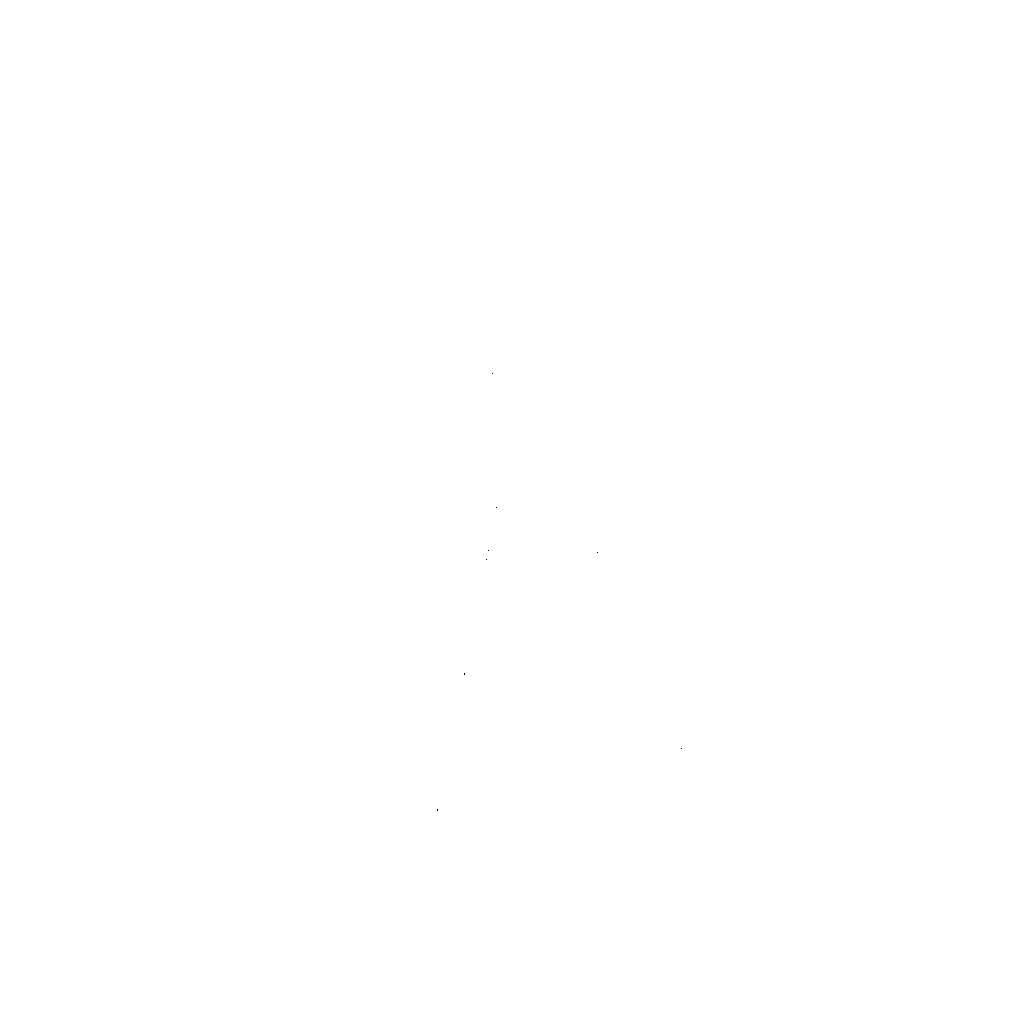

Threshold value: 50


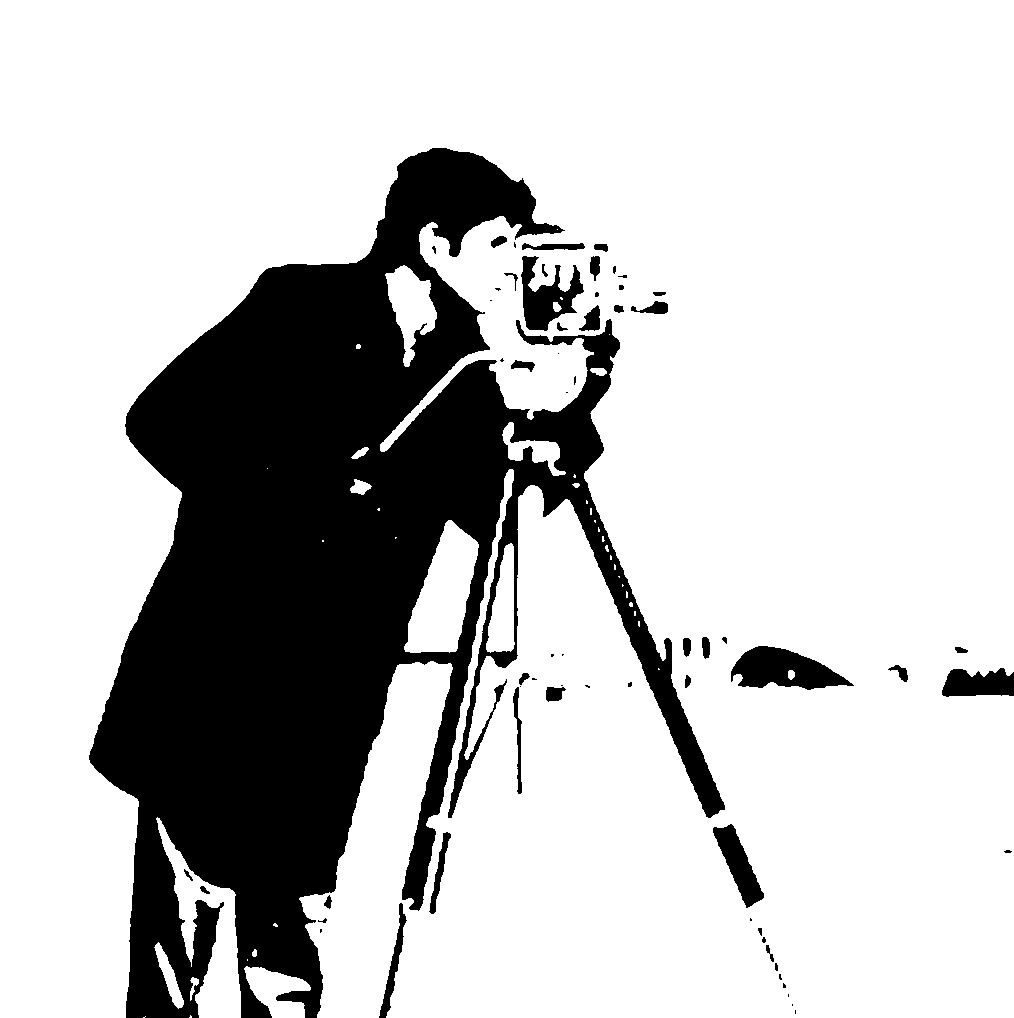

Threshold value: 100


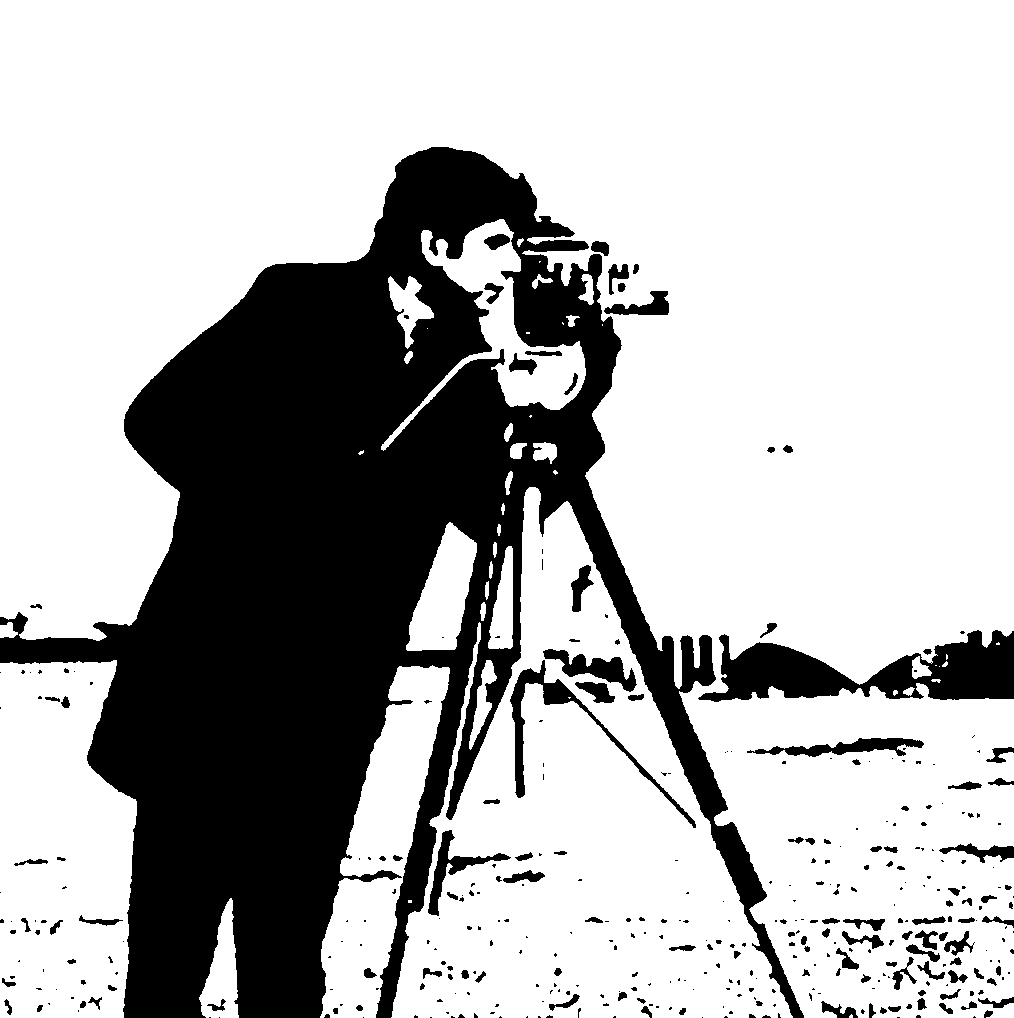

Threshold value: 150


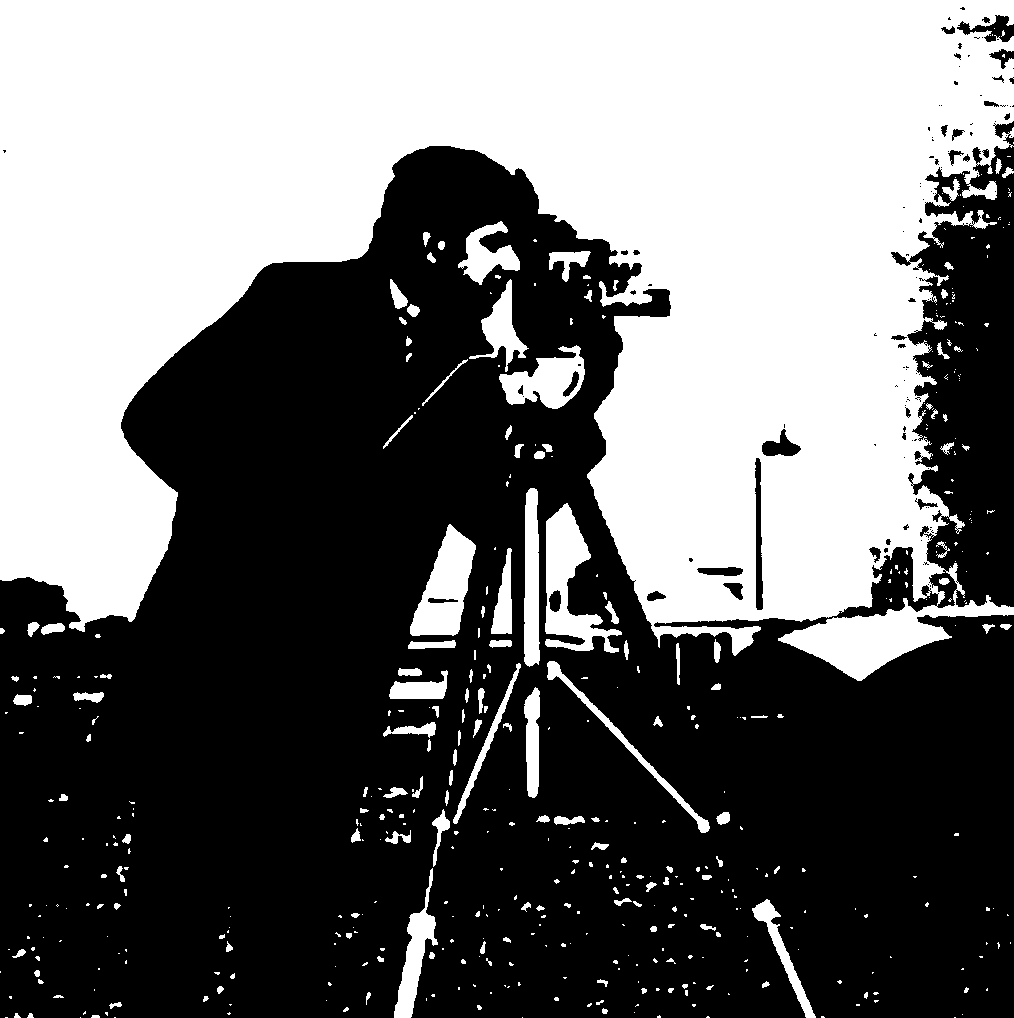

Threshold value: 200


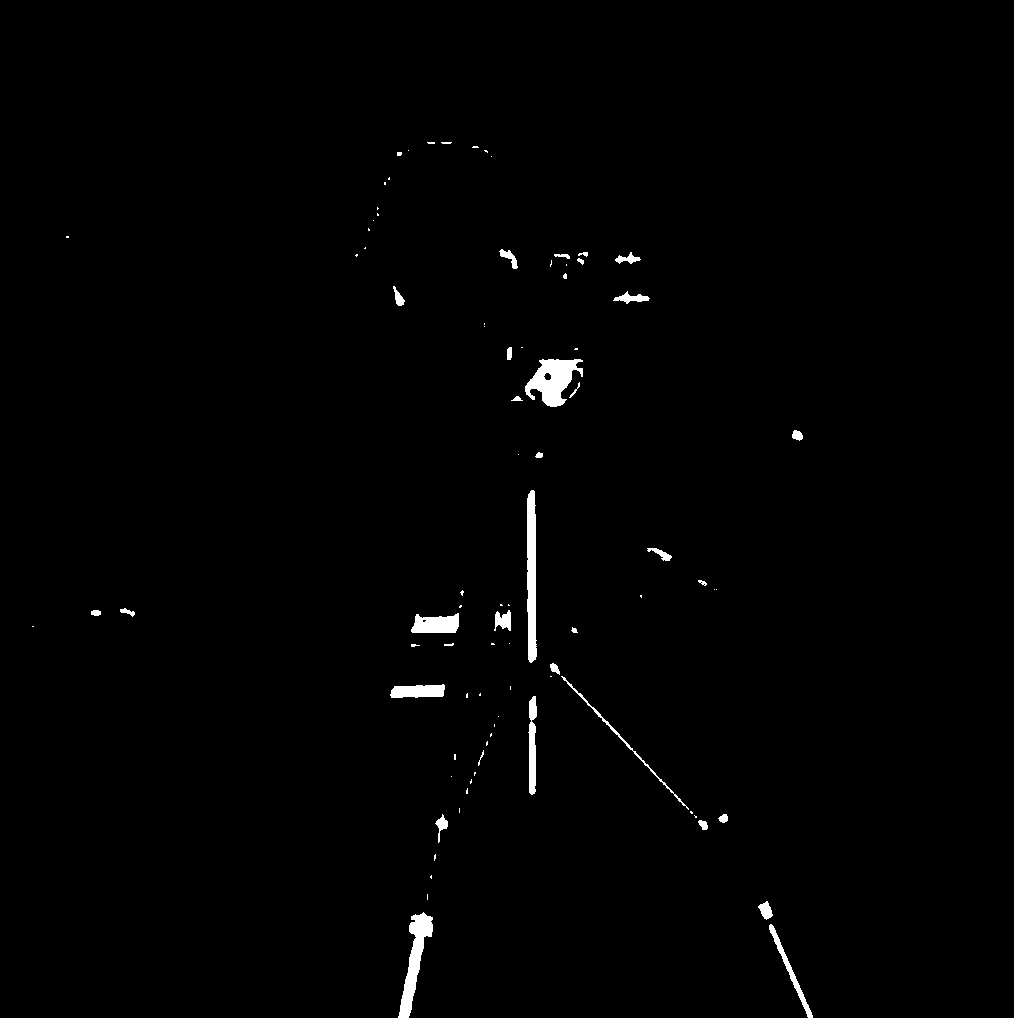

In [ ]:
import cv2

# Load the image in grayscale
img = cv2.imread('cameraman.png', cv2.IMREAD_GRAYSCALE)

# Set the threshold values
threshold_values = [0, 50, 100, 150, 200]

# Apply thresholding with different threshold values
for threshold_value in threshold_values:
    ret_thresh_value, thresh_img = cv2.threshold(img, threshold_value, 255, cv2.THRESH_BINARY)

    print(f"Threshold value: {threshold_value}")
    cv2_imshow(thresh_img)

Original Image: 


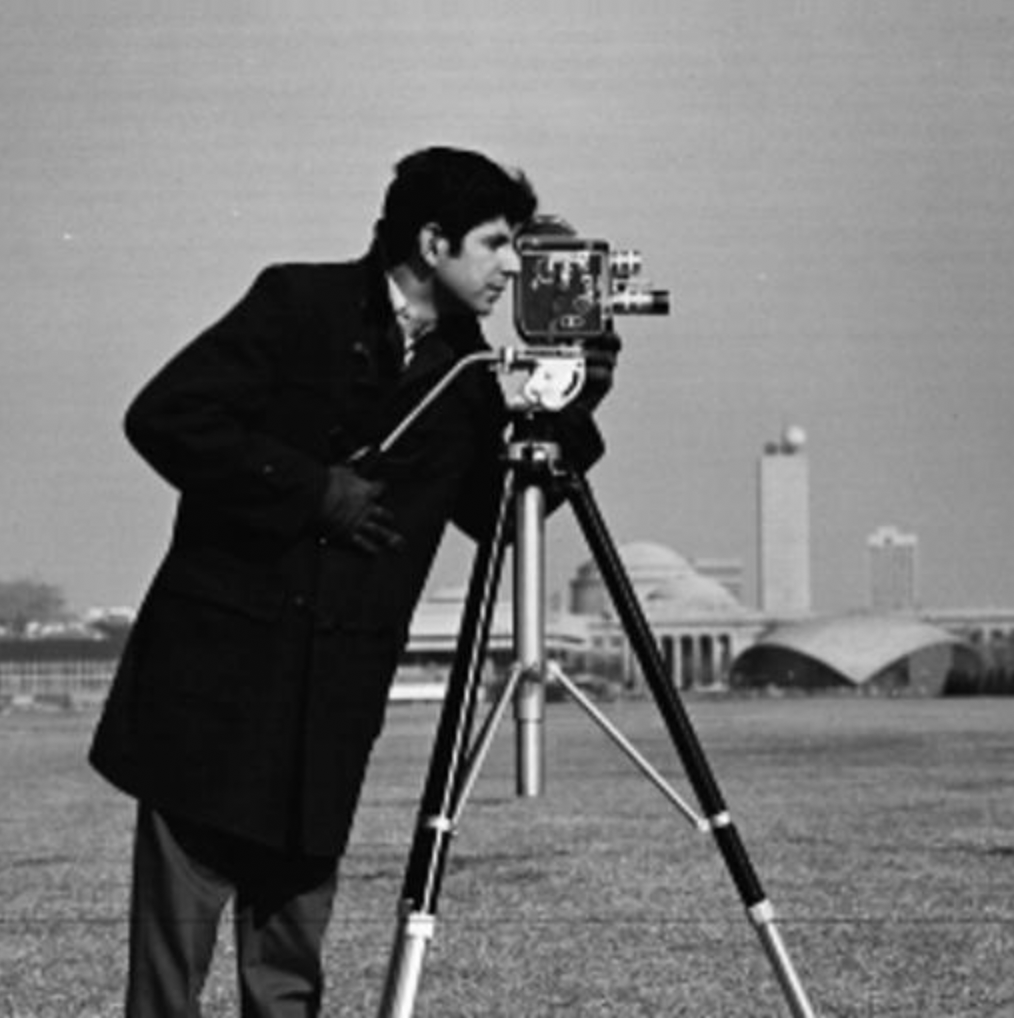

In [ ]:
print("Original Image: ")
cv2_imshow(img)

## Histograms

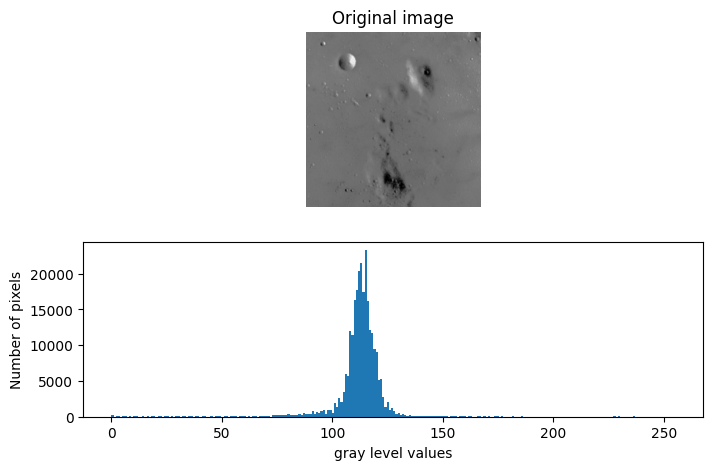

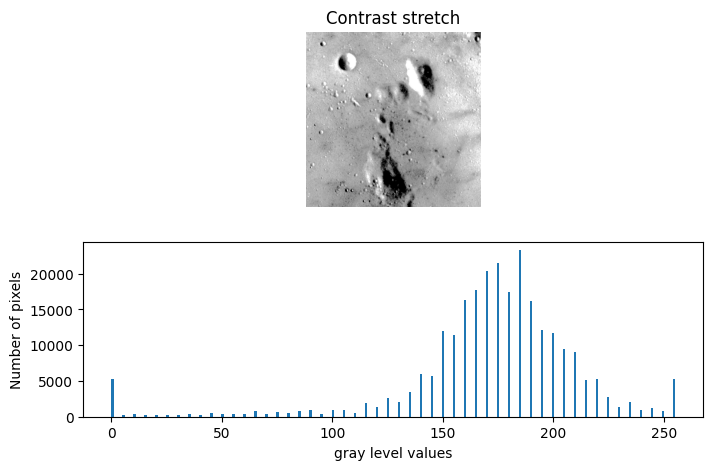

In [ ]:
# Task#2: Histogram Processing

# Step#1: Load necessary libraries
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

from skimage import data
from skimage import exposure

# Step#2: Load moon image
img = data.moon()

# Step#3: Rescale intensity values to include all the intensities that fall within the 2nd and 98th percentiles
# Contrast stretching
p2, p98 = np.percentile(img, (2, 98))
img_rescale = exposure.rescale_intensity(img, in_range=(p2, p98))

# Step#4: Display the image with its histogram of (step#2)  and (step#3)
fig = plt.figure(figsize=(8, 5))
fig.add_subplot(2, 1, 1)
plt.imshow(img, cmap = 'gray')
plt.axis('off')
plt.title('Original image')

fig.add_subplot(2, 1, 2)
plt.hist(img.flat, bins = 256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

fig = plt.figure(figsize=(8, 5))
fig.add_subplot(2, 1, 1)
plt.imshow(img_rescale, cmap = 'gray')
plt.axis('off')
plt.title('Contrast stretch')

fig.add_subplot(2, 1, 2)
plt.hist(img_rescale.flat, bins = 256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

# Tasks:

Task1: Using the same ‘moon image’ Rescale intensity values to include all the intensities that fall within the 3nd and 80th percentiles, and plot the histogram

Task2: Using the same ‘moon image’ and the exposure.equalize_hist function, display the image and the histogram of the image after flattening the histogram.

Task3: Use the rocket (as reference) and chelsea images (from skimage.data) and implement histogram matching


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, exposure

3rd percentile = 87.0, 80th percentile = 118.0


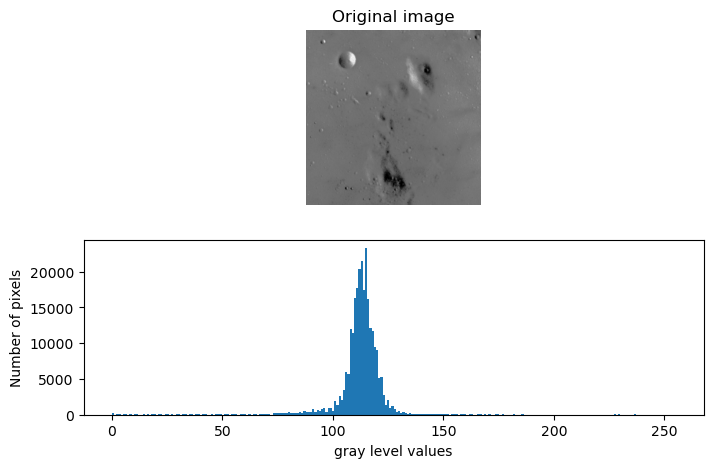

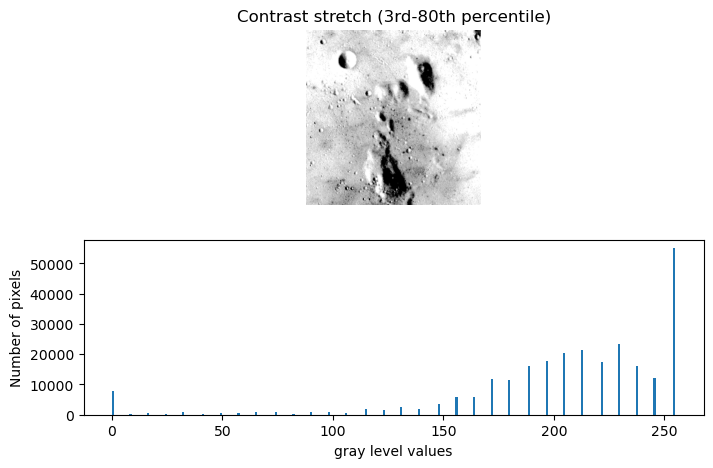

In [5]:
img = data.moon()

p3, p80 = np.percentile(img, (3, 80))
img_rescale_t1 = exposure.rescale_intensity(img, in_range=(p3, p80))

print(f"3rd percentile = {p3}, 80th percentile = {p80}")

fig = plt.figure(figsize=(8, 5))
fig.add_subplot(2, 1, 1)
plt.imshow(img, cmap='gray')
plt.axis('off')
plt.title('Original image')

fig.add_subplot(2, 1, 2)
plt.hist(img.flat, bins=256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

fig = plt.figure(figsize=(8, 5))
fig.add_subplot(2, 1, 1)
plt.imshow(img_rescale_t1, cmap='gray')
plt.axis('off')
plt.title('Contrast stretch (3rd-80th percentile)')

fig.add_subplot(2, 1, 2)
plt.hist(img_rescale_t1.flat, bins=256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

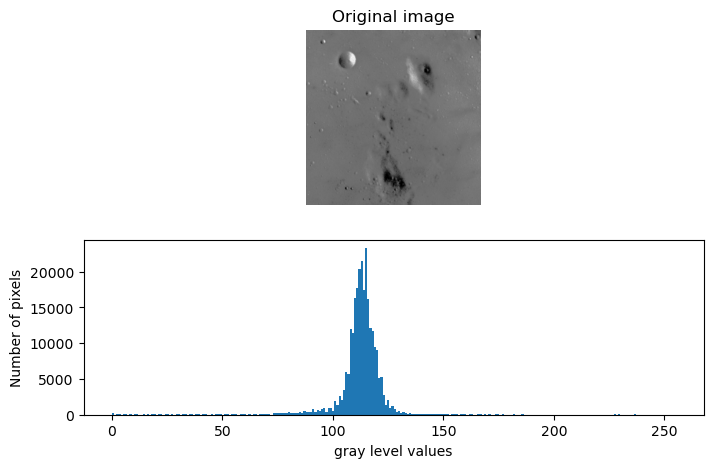

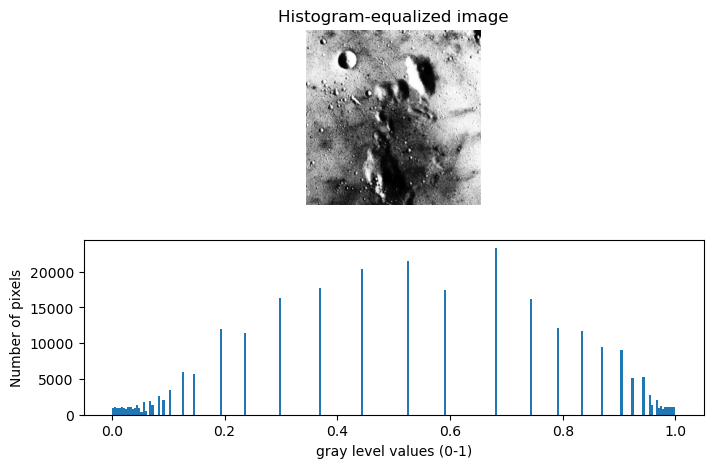

In [6]:
img = data.moon()

img_eq = exposure.equalize_hist(img)

fig = plt.figure(figsize=(8, 5))
fig.add_subplot(2, 1, 1)
plt.imshow(img, cmap='gray')
plt.axis('off')
plt.title('Original image')

fig.add_subplot(2, 1, 2)
plt.hist(img.flat, bins=256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

fig = plt.figure(figsize=(8, 5))
fig.add_subplot(2, 1, 1)
plt.imshow(img_eq, cmap='gray')
plt.axis('off')
plt.title('Histogram-equalized image')

fig.add_subplot(2, 1, 2)
plt.hist(img_eq.flat, bins=256, range=(0, 1))
plt.xlabel('gray level values (0-1)')
plt.ylabel('Number of pixels')
plt.show()

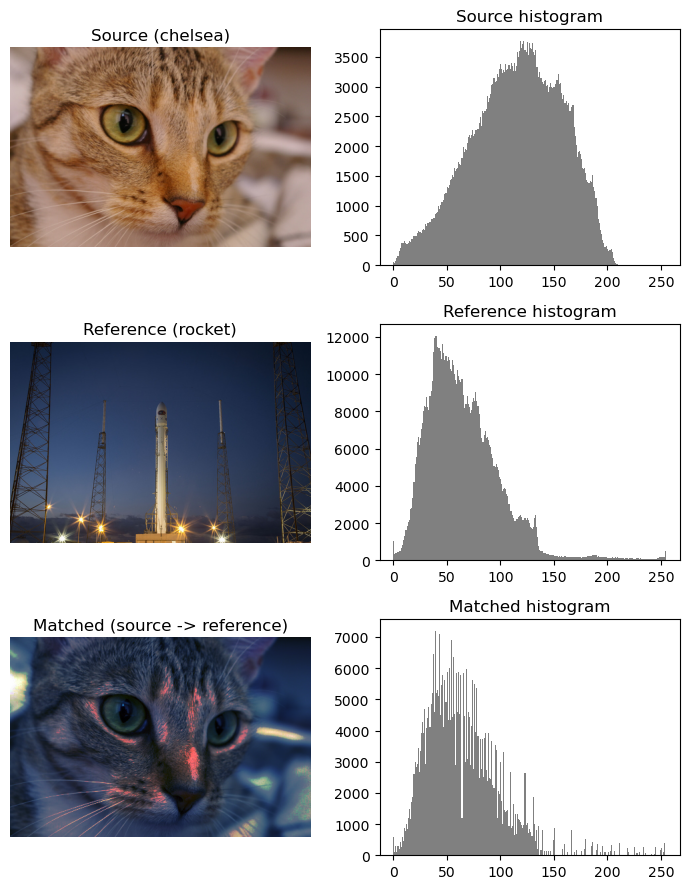

In [7]:
reference = data.rocket()
source = data.chelsea()

matched = exposure.match_histograms(source, reference, channel_axis=-1)

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(7, 9))

axes[0, 0].imshow(source)
axes[0, 0].set_title('Source (chelsea)')
axes[0, 0].axis('off')
axes[0, 1].hist(source.flat, bins=256, range=(0, 255), color='gray')
axes[0, 1].set_title('Source histogram')

axes[1, 0].imshow(reference)
axes[1, 0].set_title('Reference (rocket)')
axes[1, 0].axis('off')
axes[1, 1].hist(reference.flat, bins=256, range=(0, 255), color='gray')
axes[1, 1].set_title('Reference histogram')

axes[2, 0].imshow(matched.astype(np.uint8))
axes[2, 0].set_title('Matched (source -> reference)')
axes[2, 0].axis('off')
axes[2, 1].hist(matched.flat, bins=256, range=(0, 255), color='gray')
axes[2, 1].set_title('Matched histogram')

plt.tight_layout()
plt.show()